## 加载数据

数据已经预处理过了

In [1]:
import pandas as pd

# 加载数据
# data = pd.read_csv('../../data-hh/my/202410221653-processed.csv', dtype={'aircraft': str})
data = pd.read_csv('../../data-hh/my/202410221653-processed.csv')

# 查看前几行数据，确保加载成功
print(data.head())

         flt_no bd_type  cap aircraft  leg_no  duration  pax             a  \
0  P6p42wyZFEI=      窄体  122      319       3  1.888806    7  tKjndGSl9NQ=   
1  P6p42wyZFEI=      窄体  132      319       2  2.680000   56  tKjndGSl9NQ=   
2  P6p42wyZFEI=      窄体  132      319       1  2.380000  113  tKjndGSl9NQ=   
3  fu7RYrFYvDk=      窄体  122      319       3  1.888806   26  5t+HPO9Mu/w=   
4  fu7RYrFYvDk=      窄体  132      319       2  1.720000   23  5t+HPO9Mu/w=   

              b             c  ...            to  year  month  day  weekday  \
0  KETr2NAmAHE=  5t+HPO9Mu/w=  ...  5t+HPO9Mu/w=  2023      1    1        6   
1  KETr2NAmAHE=  5t+HPO9Mu/w=  ...  5t+HPO9Mu/w=  2023      1    1        6   
2  KETr2NAmAHE=  5t+HPO9Mu/w=  ...  KETr2NAmAHE=  2023      1    1        6   
3  KETr2NAmAHE=  tKjndGSl9NQ=  ...  tKjndGSl9NQ=  2023      1    1        6   
4  KETr2NAmAHE=  tKjndGSl9NQ=  ...  tKjndGSl9NQ=  2023      1    1        6   

   holiday  hour  minute  second   unit_price  
0     Tr

In [2]:
data.info()   #information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376884 entries, 0 to 376883
Data columns (total 21 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   flt_no      376884 non-null  object 
 1   bd_type     376884 non-null  object 
 2   cap         376884 non-null  int64  
 3   aircraft    376884 non-null  object 
 4   leg_no      376884 non-null  int64  
 5   duration    376884 non-null  float64
 6   pax         376884 non-null  int64  
 7   a           376884 non-null  object 
 8   b           376884 non-null  object 
 9   c           376884 non-null  object 
 10  from        376884 non-null  object 
 11  to          376884 non-null  object 
 12  year        376884 non-null  int64  
 13  month       376884 non-null  int64  
 14  day         376884 non-null  int64  
 15  weekday     376884 non-null  int64  
 16  holiday     376884 non-null  bool   
 17  hour        376884 non-null  int64  
 18  minute      376884 non-null  int64  
 19  se

In [3]:
# 查看 'cap' 列中每个元素的数据类型
print(data['cap'].apply(type).value_counts())

cap
<class 'int'>    376884
Name: count, dtype: int64


In [4]:
# 查看 'cap' 列中每个元素的数据类型
print(data['aircraft'].apply(type).value_counts())

aircraft
<class 'str'>    376884
Name: count, dtype: int64


In [5]:
unique_values = data.iloc[:, 3].unique()  # 通过列索引查看数据的唯一值
print(unique_values)

['319' '320' '330' '321' '737' '738' 'ARJ' 'CRJ' 'ERJ' '190' '787' '350'
 '789']


In [6]:
unique_values = data.iloc[:, 2].unique()  # 通过列索引查看数据的唯一值
print(unique_values)

[122 132 158 164 274 189 194 201 180 186 178 176 200 159 167 138 152 172
 160 195 166 128 170  90 174  89  95 210 111 104 198 207 144 168 190 184
 182 162 134  98 220 177 208 130 179 169 135 161 283 300 266 285 175 279
 234 185 232 264 294 288 301 287 297 314  78]


## 编码分类变量

In [7]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

In [8]:
from joblib import dump

# 1. 获取所有唯一城市集合
# all_cities = pd.unique(data[['a', 'b', 'c', 'from', 'to']].values.ravel())

# 2. 为每列生成独热编码规则并对数据进行编码
encoders = {}
encoded_features = []

for col in ['a', 'b', 'c', 'from', 'to']:
    # 生成独热编码规则
    encoder = pd.get_dummies(data[col], prefix=col).columns.tolist()
    encoders[col] = encoder
    
    # 对当前列进行独热编码
    encoded_col = pd.get_dummies(data[col], prefix=col)
    encoded_features.append(encoded_col)

# 合并独热编码后的特征到原始数据
encoded_df = pd.concat([data] + encoded_features, axis=1)

# 删除原始的 'a', 'b', 'c', 'from', 'to' 列
encoded_df = encoded_df.drop(columns=['a', 'b', 'c', 'from', 'to'])

# 保存编码规则到文件
encoder_save_path = '../../data-hh/my/encoder/city_encoders.joblib'
dump(encoders, encoder_save_path)

# 输出结果
print("已保存的编码器规则:")
for col, encoder in encoders.items():
    print(f"{col}: {encoder}")

print("\n编码后的 DataFrame:")
print(encoded_df)


已保存的编码器规则:
a: ['a_+3eoTOkHfoU=', 'a_+O1iBQtlFGU=', 'a_+cjxQ01BFmw=', 'a_/M8gHzjxpNU=', 'a_/NwmlZilpx8=', 'a_/Qfhw+Rw8Uc=', 'a_/qxKZMQeBus=', 'a_07fT2dsZOJM=', 'a_0J4jz5aCatU=', 'a_0Koyk9pJc0s=', 'a_1/9nd1jNCE0=', 'a_1cc42TkiQ7Y=', 'a_1drohyZiaWg=', 'a_1yjwuTyIA9Q=', 'a_2jt80AsNp3c=', 'a_3nMB4t9SNGw=', 'a_4Fw2OP3Kivk=', 'a_4J2zqjPuTyI=', 'a_4Liydpz6+ug=', 'a_4ZGZ6nzQlkY=', 'a_4j3sFPu6XuA=', 'a_5EzFgY1LGWA=', 'a_5nSr6ORvvgE=', 'a_5rOli53EwQQ=', 'a_5t+HPO9Mu/w=', 'a_6DrljiIyDa4=', 'a_7C34qLmTO2o=', 'a_81MA7ppp7mI=', 'a_8Oz/xamw3iQ=', 'a_8jksZMFqgdA=', 'a_9CKiQhwf53g=', 'a_9f4R9J9ealY=', 'a_9j4ofoSZvc4=', 'a_9obCP1myMDU=', 'a_A7/aBOh5mik=', 'a_AA/y/svu7dU=', 'a_AKQNtuL5r6Q=', 'a_AN5qixNqwJQ=', 'a_AfKac4FzdXs=', 'a_AlGb30xUGAU=', 'a_Ane1Z6nPv94=', 'a_AqmhSoBTk6M=', 'a_BQh70OS5XkI=', 'a_C3VfOpfT580=', 'a_CnmNtb5MOJA=', 'a_CoDVS1ItQjM=', 'a_CqvRquR8cfs=', 'a_D+4URFpQP0E=', 'a_D/g4DKpG/lk=', 'a_DInJHXgQayE=', 'a_DMRxgT4Xheg=', 'a_DUbxF00Y8a0=', 'a_EF4D0LqfA8Q=', 'a_EF9aodHSh3E=', 'a_EIsXRbFUH3

In [9]:
encoded_df.info()   #information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376884 entries, 0 to 376883
Columns: 1003 entries, flt_no to to_zwVGiYamVc0=
dtypes: bool(988), float64(2), int64(10), object(3)
memory usage: 398.2+ MB


In [10]:
import pandas as pd
from joblib import dump, load

# 加载已保存的编码器（若存在），否则初始化空字典
encoder_save_path = '../../data-hh/my/encoder/city_encoders.joblib'
try:
    encoders = load(encoder_save_path)
    print(f"成功加载已有编码器规则: {encoder_save_path}")
except FileNotFoundError:
    encoders = {}
    print("编码器文件不存在，初始化新的编码器规则。")

# 为 'flt_no', 'bd_type', 'aircraft' 生成独热编码规则并对数据进行编码
encoded_features = []
for col in ['flt_no', 'bd_type', 'aircraft']:
    # 生成独热编码规则并更新到编码器
    encoder = pd.get_dummies(encoded_df[col], prefix=col).columns.tolist()
    encoders[col] = encoder
    
    # 对当前列进行独热编码
    encoded_col = pd.get_dummies(encoded_df[col], prefix=col)
    encoded_features.append(encoded_col)

# 合并独热编码后的特征到原始数据
encoded_df = pd.concat([encoded_df] + encoded_features, axis=1)

# 删除原始的 'flt_no', 'bd_type', 'aircraft' 列
encoded_df = encoded_df.drop(columns=['flt_no', 'bd_type', 'aircraft'])

# 保存更新后的编码规则到文件
dump(encoders, encoder_save_path)

# 输出结果
print("已保存的编码器规则:")
print(f"保存路径: {encoder_save_path}")
for col, encoder in encoders.items():
    print(f"{col}: {encoder}")

print("\n编码后的 DataFrame:")
print(encoded_df)

成功加载已有编码器规则: ../../data-hh/my/encoder/city_encoders.joblib
已保存的编码器规则:
保存路径: ../../data-hh/my/encoder/city_encoders.joblib
a: ['a_+3eoTOkHfoU=', 'a_+O1iBQtlFGU=', 'a_+cjxQ01BFmw=', 'a_/M8gHzjxpNU=', 'a_/NwmlZilpx8=', 'a_/Qfhw+Rw8Uc=', 'a_/qxKZMQeBus=', 'a_07fT2dsZOJM=', 'a_0J4jz5aCatU=', 'a_0Koyk9pJc0s=', 'a_1/9nd1jNCE0=', 'a_1cc42TkiQ7Y=', 'a_1drohyZiaWg=', 'a_1yjwuTyIA9Q=', 'a_2jt80AsNp3c=', 'a_3nMB4t9SNGw=', 'a_4Fw2OP3Kivk=', 'a_4J2zqjPuTyI=', 'a_4Liydpz6+ug=', 'a_4ZGZ6nzQlkY=', 'a_4j3sFPu6XuA=', 'a_5EzFgY1LGWA=', 'a_5nSr6ORvvgE=', 'a_5rOli53EwQQ=', 'a_5t+HPO9Mu/w=', 'a_6DrljiIyDa4=', 'a_7C34qLmTO2o=', 'a_81MA7ppp7mI=', 'a_8Oz/xamw3iQ=', 'a_8jksZMFqgdA=', 'a_9CKiQhwf53g=', 'a_9f4R9J9ealY=', 'a_9j4ofoSZvc4=', 'a_9obCP1myMDU=', 'a_A7/aBOh5mik=', 'a_AA/y/svu7dU=', 'a_AKQNtuL5r6Q=', 'a_AN5qixNqwJQ=', 'a_AfKac4FzdXs=', 'a_AlGb30xUGAU=', 'a_Ane1Z6nPv94=', 'a_AqmhSoBTk6M=', 'a_BQh70OS5XkI=', 'a_C3VfOpfT580=', 'a_CnmNtb5MOJA=', 'a_CoDVS1ItQjM=', 'a_CqvRquR8cfs=', 'a_D+4URFpQP0E=', 'a_D/g4DKp

In [11]:
# 查看处理后的数据
print(encoded_df.head())

   cap  leg_no  duration  pax  year  month  day  weekday  holiday  hour  ...  \
0  122       3  1.888806    7  2023      1    1        6     True     8  ...   
1  132       2  2.680000   56  2023      1    1        6     True    12  ...   
2  132       1  2.380000  113  2023      1    1        6     True     8  ...   
3  122       3  1.888806   26  2023      1    1        6     True    16  ...   
4  132       2  1.720000   23  2023      1    1        6     True    20  ...   

   aircraft_321  aircraft_330  aircraft_350  aircraft_737  aircraft_738  \
0         False         False         False         False         False   
1         False         False         False         False         False   
2         False         False         False         False         False   
3         False         False         False         False         False   
4         False         False         False         False         False   

   aircraft_787  aircraft_789  aircraft_ARJ  aircraft_CRJ  aircraft_

## 特征和目标分离
我们要预测的是pax字段，其他字段作为特征。

In [12]:
# 目标列
y = encoded_df['pax']

# 特征列（去除目标列 'pax' 和可能的非特征列）
X = encoded_df.drop(columns=['pax'])

# 查看特征列数目
print("特征列数目:", X.shape[1])


特征列数目: 3804


## 训练XGBoost模型

In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from tqdm import tqdm

# 假设数据已加载到 X 和 y 中
# 示例代码：X, y = 数据的特征和目标值

# 将数据分为训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 转换为 DMatrix 格式
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# 设置参数
params = {
    'objective': 'reg:squarederror',
    'max_depth': 8,
    'min_child_weight': 3,
    'gamma': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.9,
    'learning_rate': 0.01,
    'eval_metric': 'rmse'
}

# 自定义回调函数，用于进度条
class TQDMCallback(xgb.callback.TrainingCallback):
    def __init__(self, total_epochs):
        self.progress_bar = tqdm(total=total_epochs, desc="训练进度", unit="epoch")

    def after_iteration(self, model, epoch, evals_log):
        self.progress_bar.update(1)  # 每次迭代更新进度条
        return False  # 不提前终止训练

    def after_training(self, model):
        self.progress_bar.close()  # 训练结束关闭进度条
        return model  # 必须返回模型实例

# 总迭代轮数
num_boost_round = 1000
callback = TQDMCallback(total_epochs=num_boost_round)

# 开始训练
print("开始训练模型...")
evals = [(dtrain, 'train'), (dtest, 'test')]
model = xgb.train(params, dtrain, num_boost_round=num_boost_round, evals=evals, callbacks=[callback])

# 预测测试集
y_pred = model.predict(dtest)


训练进度:   0%|                                                                                                                                            | 0/1000 [00:00<?, ?epoch/s]

开始训练模型...


训练进度:   0%|▏                                                                                                                                   | 1/1000 [00:03<51:42,  3.11s/epoch]

[0]	train-rmse:41.01156	test-rmse:41.07294


训练进度:   0%|▎                                                                                                                                   | 2/1000 [00:03<24:25,  1.47s/epoch]

...

训练进度: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 999/1000 [03:45<00:00,  4.30epoch/s]

[998]	train-rmse:27.60369	test-rmse:27.89377


训练进度: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:45<00:00,  4.77epoch/s]

[999]	train-rmse:27.60239	test-rmse:27.89252


训练进度: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:45<00:00,  4.43epoch/s]


In [14]:
# 显示20条测试结果（真实值 vs 预测值）
test_results = list(zip(y_test.values[:40], y_pred[:40]))  # 真实值和预测值
print("\n20条测试结果（真实值 vs 预测值）:")
for i, (true_value, pred_value) in enumerate(test_results):
    print(f"第{i+1}条: 真实值={true_value}, 预测值={pred_value:.2f}")


20条测试结果（真实值 vs 预测值）:
第1条: 真实值=62, 预测值=64.39
第2条: 真实值=23, 预测值=70.24
第3条: 真实值=125, 预测值=93.03
第4条: 真实值=103, 预测值=94.71
第5条: 真实值=112, 预测值=97.59
第6条: 真实值=22, 预测值=64.23
第7条: 真实值=85, 预测值=53.92
第8条: 真实值=112, 预测值=90.78
第9条: 真实值=55, 预测值=37.52
第10条: 真实值=76, 预测值=63.83
第11条: 真实值=42, 预测值=78.95
第12条: 真实值=56, 预测值=78.16
第13条: 真实值=11, 预测值=41.10
第14条: 真实值=131, 预测值=91.91
第15条: 真实值=70, 预测值=101.00
第16条: 真实值=127, 预测值=62.83
第17条: 真实值=20, 预测值=55.29
第18条: 真实值=118, 预测值=145.29
第19条: 真实值=68, 预测值=47.33
第20条: 真实值=141, 预测值=96.21
第21条: 真实值=83, 预测值=76.13
第22条: 真实值=54, 预测值=71.35
第23条: 真实值=29, 预测值=50.59
第24条: 真实值=50, 预测值=71.92
第25条: 真实值=106, 预测值=87.77
第26条: 真实值=101, 预测值=96.66
第27条: 真实值=30, 预测值=37.59
第28条: 真实值=95, 预测值=57.02
第29条: 真实值=7, 预测值=39.38
第30条: 真实值=72, 预测值=83.07
第31条: 真实值=21, 预测值=52.10
第32条: 真实值=39, 预测值=38.56
第33条: 真实值=41, 预测值=47.56
第34条: 真实值=24, 预测值=69.03
第35条: 真实值=123, 预测值=94.84
第36条: 真实值=91, 预测值=95.33
第37条: 真实值=155, 预测值=90.00
第38条: 真实值=55, 预测值=84.82
第39条: 真实值=66, 预测值=78.85
第40条: 真实值=101, 预测值=94.28


似乎对于较小值预测存在误差

## 误差检测

R2 Score (决定系数)

MAE (Mean Absolute Error, 平均绝对误差)

MSE (Mean Squared Error, 均方误差)

RMSE (Root Mean Squared Error, 均方根误差)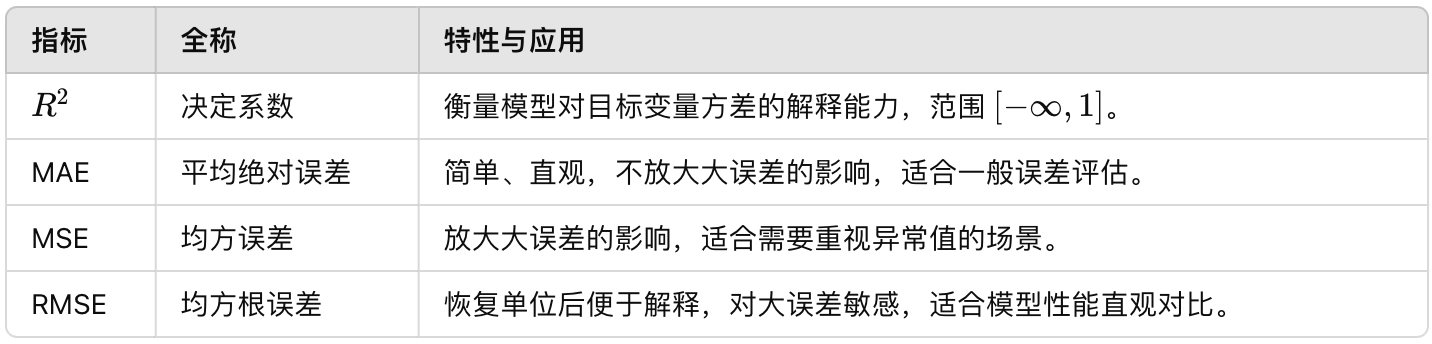

In [15]:
def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return smape

def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 评估模型
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')

Mean Squared Error (MSE): 777.9927
Root Mean Squared Error (RMSE): 27.8925
Mean Absolute Error (MAE): 22.8001
Mean Absolute Percentage Error (MAPE): 99.8715%
Symmetric Mean Absolute Percentage Error (SMAPE): 41.5576%


## 保存模型

In [17]:
model.save_model("xgboost_model.json")
print("模型已保存为 xgboost_model.json")

模型已保存为 xgboost_model.json


In [18]:
import pandas as pd

# 示例数据
data = {
    'a': ['X1', 'X2', 'X1', 'X3', 'X2'],
    'b': ['X1', 'Y2', 'X1', 'Y3', 'Y3'],
    'c': ['Z1', 'Z2', 'Z1', 'Z3', 'Z2'],
    'from': ['X1', 'Y2', 'Z1', 'X3', 'X2'],
    'to': ['X1', 'Z2', 'X1', 'Z3', 'Z1']
}

df = pd.DataFrame(data)

# 1. 获取所有唯一城市集合
all_cities = pd.unique(df[['a', 'b', 'c', 'from', 'to']].values.ravel())

# 2. 对每列进行独热编码，基于统一城市集合，保留列的来源信息
encoded_columns = []
for col in ['a', 'b', 'c', 'from', 'to']:
    encoded_col = pd.get_dummies(df[col], prefix=col)
    encoded_columns.append(encoded_col)

# 3. 合并独热编码后的列与原始数据
encoded_df = pd.concat([df] + encoded_columns, axis=1)

# 输出结果
print("所有城市集合:")
print(all_cities)
print("\n嵌套独热编码后的 DataFrame:")
print(encoded_df)


所有城市集合:
['X1' 'Z1' 'X2' 'Y2' 'Z2' 'X3' 'Y3' 'Z3']

嵌套独热编码后的 DataFrame:
    a   b   c from  to   a_X1   a_X2   a_X3   b_X1   b_Y2  ...   c_Z3  \
0  X1  X1  Z1   X1  X1   True  False  False   True  False  ...  False   
1  X2  Y2  Z2   Y2  Z2  False   True  False  False   True  ...  False   
2  X1  X1  Z1   Z1  X1   True  False  False   True  False  ...  False   
3  X3  Y3  Z3   X3  Z3  False  False   True  False  False  ...   True   
4  X2  Y3  Z2   X2  Z1  False   True  False  False  False  ...  False   

   from_X1  from_X2  from_X3  from_Y2  from_Z1  to_X1  to_Z1  to_Z2  to_Z3  
0     True    False    False    False    False   True  False  False  False  
1    False    False    False     True    False  False  False   True  False  
2    False    False    False    False     True   True  False  False  False  
3    False    False     True    False    False  False  False  False   True  
4    False     True    False    False    False  False   True  False  False  

[5 rows x 23 columns]
